In [ ]:
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns


In [3]:
DATA_DIR = "./data"
IMAGES_DIR = f"{DATA_DIR}/images"
CLASSES = ["Tom", "None", "Jerry", "Both"]
NUM_CLASSES = len(CLASSES)

## EXPLORATORY DATA ANALYSIS

### Extensions analysis

In [4]:
extensions = {
    os.path.splitext(entry.name)[1].lower()
    for folder in os.listdir(IMAGES_DIR)
    for entry in os.scandir(f"{IMAGES_DIR}/{folder}")
    if entry.is_file()
}

print(f"Found {len(extensions)} unique file extensions: {extensions}")

Found 1 unique file extensions: {'.jpg'}


### Distribution of the images according to the label

In [5]:
counts = {}
for class_name, class_path in zip(CLASSES, os.listdir(IMAGES_DIR)):
    class_dir = f"{IMAGES_DIR}/{class_path}"
    counts[class_name] = len([entry for entry in os.scandir(class_dir) if entry.is_file()])

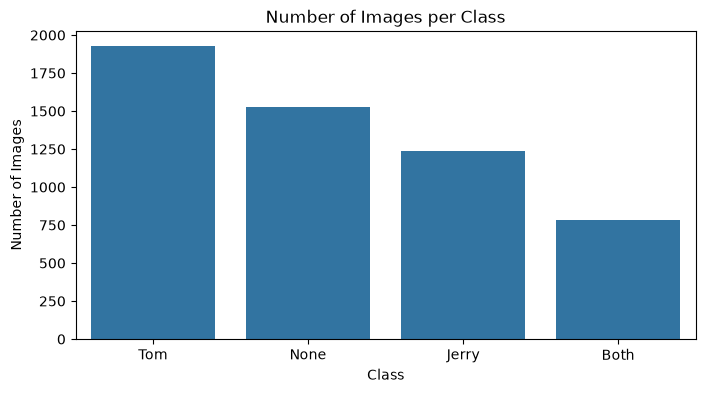

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

### Displaying a sample

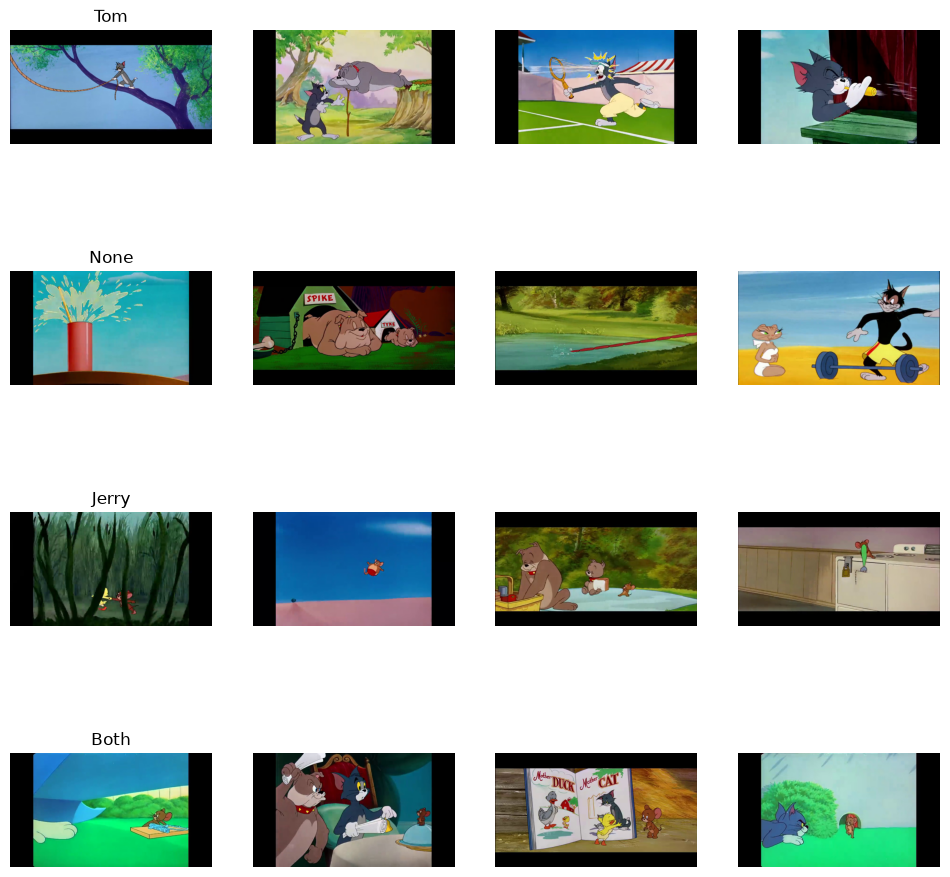

In [7]:
num_samples = 4

fig, axes = plt.subplots(NUM_CLASSES, num_samples, 
                         figsize=(NUM_CLASSES * 3, num_samples * 3))
for i, class_path in enumerate(os.listdir(IMAGES_DIR)):
    class_dir = f"{IMAGES_DIR}/{class_path}"
    image_files = [entry.path for entry in os.scandir(class_dir) if entry.is_file()]
    sampled_images = random.sample(image_files, num_samples)
    
    for j, image_path in enumerate(sampled_images):
        img = plt.imread(image_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(CLASSES[i])

### Image dimensions

In [8]:
dimensions = []
for class_path in os.listdir(IMAGES_DIR):
    class_dir = f"{IMAGES_DIR}/{class_path}"
    for entry in os.scandir(class_dir):
        if entry.is_file():
            img = Image.open(entry.path)
            dimensions.append(img.size) 

dim_counter = Counter(dimensions)
print("Image dimensions and their counts:")
for dim, count in dim_counter.items():
    print(f"{dim}: {count}")

Image dimensions and their counts:
(1280, 720): 1283
(854, 480): 4195


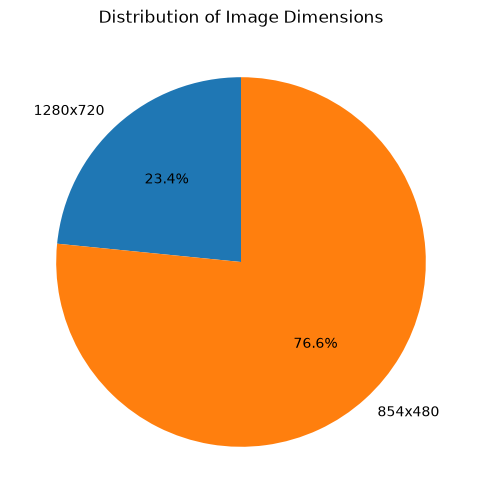

In [9]:
# There are only 2 types of dimensions, so the pie plot will visualize the distribution of these two types of dimensions.
dim_labels = [f"{dim[0]}x{dim[1]}" for dim in dim_counter.keys()]
plt.figure(figsize=(6, 6))
plt.pie(dim_counter.values(), labels=dim_labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Image Dimensions")
plt.show()